In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
import pandas as pd
from QAESimulator import QAEQulacs
from MLEUtil import FindAmpSqMLE

In [2]:
np.random.seed(1)

In [3]:
ampSqTrue = 0.3
nQueryMax = 2 ** 16
nShots = 2 ** np.arange(11)
nGroverMaxs = (nQueryMax / nShots).astype(int)
nRepeat = 50

In [10]:
dfColNames = ["nShot", "nGroverMax"] + [str(i) for i in range(nRepeat)] 
ampSqEstimsMat = pd.DataFrame(columns=dfColNames)

for nShot, nGroverMax in zip(nShots, nGroverMaxs):
    ampSqEstims = []
    for _ in range(nRepeat):
        nGrovers, n1s = QAEQulacs(ampSqTrue, nShot, nGroverMax)
        ampSqEstims += [FindAmpSqMLE(nGrovers, n1s, nShot)]
    ampSqEstimsMat = pd.concat([ampSqEstimsMat, pd.DataFrame(data=[[nShot, nGroverMax] + ampSqEstims], columns=dfColNames)])
    
filename = "err_ampSqTure=" + str(ampSqTrue) + "_" + datetime.datetime.now().strftime('%Y%m%d%H%M%S') + ".csv"
ampSqEstimsMat.to_csv("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/" + filename, index=False)    

C:\Users\koich\Desktop\Code\QAEErrorVsNShotNGrover\MLEUtil.py:9: RuntimeWarning: divide by zero encountered in log
  ret += n1 * np.log(p) + (nShot - n1) * np.log(1.0 - p)
C:\Users\koich\Desktop\Code\QAEErrorVsNShotNGrover\MLEUtil.py:9: RuntimeWarning: invalid value encountered in multiply
  ret += n1 * np.log(p) + (nShot - n1) * np.log(1.0 - p)


In [6]:
df = pd.read_csv('C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/err_ampSqTure=0.3_20230807200045.csv')
df.iloc[:,2:len(df.columns)] -= ampSqTrue

In [7]:
df["ErrMean"] = df.iloc[:,2:52].abs().mean(axis='columns')
df["ErrMax"] = df.iloc[:,2:52].abs().max(axis='columns')
df["ErrMin"] = df.iloc[:,2:52].abs().min(axis='columns')

In [8]:
df

,nShot,nGroverMax,0,1,2,3,4,5,6,7,...,43,44,45,46,47,48,49,ErrMean,ErrMax,ErrMin
0,1,65536,1.726011e-04,-2.045085e-01,-2.960574e-01,-2.045085e-01,-8.540408e-02,-2.045085e-01,-2.891965e-01,-4.395421e-02,...,-8.402203e-03,-1.600128e-01,-1.721336e-07,-1.721336e-07,-2.960574e-01,1.416369e-01,-1.153847e-02,0.117750,0.299965,1.721336e-07
1,2,32768,8.621092e-05,-1.721336e-07,1.905915e-01,1.411639e-03,6.356403e-01,1.422455e-05,-1.721336e-07,-1.721336e-07,...,-1.721336e-07,-1.721336e-07,1.905915e-01,-8.402203e-03,-8.555883e-02,-8.555883e-02,1.783141e-01,0.046424,0.635640,1.721336e-07
2,4,16384,-1.721336e-07,2.825332e-03,-1.456862e-05,-3.317325e-02,-1.721336e-07,-1.721336e-07,-1.456862e-05,-1.721336e-07,...,-1.721336e-07,-1.721336e-07,-1.721336e-07,-1.721336e-07,-1.721336e-07,-1.456862e-05,-1.456862e-05,0.002676,0.083026,1.721336e-07
3,8,8192,-1.721336e-07,-2.896491e-05,-1.721336e-07,-1.721336e-07,-1.721336e-07,-1.721336e-07,-1.721336e-07,1.422455e-05,...,-1.721336e-07,-2.896491e-05,-1.456862e-05,-1.721336e-07,2.810897e-03,2.825332e-03,-1.721336e-07,0.003936,0.190576,1.721336e-07
4,16,4096,-1.721336e-07,1.422455e-05,-1.456862e-05,1.422455e-05,-1.456862e-05,-1.456862e-05,-1.456862e-05,-1.153385e-04,...,-1.721336e-07,-1.721336e-07,-1.456862e-05,-1.456862e-05,1.422455e-05,-1.721336e-07,-1.721336e-07,0.000013,0.000115,1.721336e-07
5,32,2048,-1.721336e-07,1.422455e-05,2.862143e-05,1.422455e-05,1.422455e-05,-1.721336e-07,-1.721336e-07,-1.721336e-07,...,-1.721336e-07,1.422455e-05,-2.896491e-05,-1.456862e-05,-1.456862e-05,5.741578e-05,-1.456862e-05,0.000016,0.000086,1.721336e-07
6,64,1024,2.862143e-05,-2.896491e-05,4.301851e-05,1.422455e-05,1.422455e-05,2.862143e-05,-1.456862e-05,-1.456862e-05,...,-1.721336e-07,1.422455e-05,1.422455e-05,-1.721336e-07,-1.456862e-05,1.422455e-05,-1.456862e-05,0.000028,0.000144,1.721336e-07
7,128,512,2.862143e-05,-2.896491e-05,-1.721336e-07,-1.456862e-05,2.862143e-05,-1.721336e-07,-2.896491e-05,-2.896491e-05,...,-4.336100e-05,-5.775689e-05,2.862143e-05,1.422455e-05,7.181325e-05,-1.456862e-05,-5.775689e-05,0.000026,0.000101,1.721336e-07
8,256,256,-1.721336e-07,4.301851e-05,4.301851e-05,-2.896491e-05,2.862143e-05,-7.215258e-05,-5.775689e-05,-2.896491e-05,...,-1.456862e-05,-1.456862e-05,8.621092e-05,-4.336100e-05,-8.654808e-05,-2.896491e-05,-1.009434e-04,0.000041,0.000101,1.721336e-07
9,512,128,-2.896491e-05,-1.456862e-05,2.862143e-05,1.422455e-05,-8.654808e-05,1.422455e-05,2.862143e-05,-1.721336e-07,...,5.741578e-05,-2.896491e-05,-7.215258e-05,2.862143e-05,4.301851e-05,1.582022e-04,-4.336100e-05,0.000044,0.000158,1.721336e-07


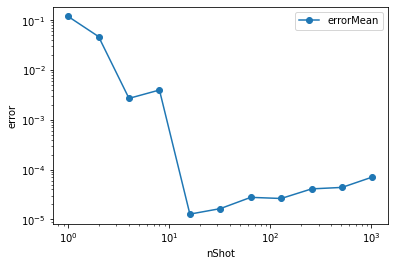

In [9]:
plt.xlabel('nShot')
plt.ylabel('error')

# 描画
ax = plt.gca()
ax.set_xscale('log')
ax.set_yscale('log')
plt.plot(df["nShot"], df["ErrMean"], label="errorMean", marker="o")

ax.legend()
plt.show()

この挙動はbiasは関係なく、統計誤差によるもの。

フィッシャー情報量： I ～ Nshot * NGrov^2

統計誤差：e ～ 1/\sqrt{I} ～ \sqrt{Nshot} / Ntot^2 （Ntot = Nshot * NGrov）

↑のグラフは右側でだいたい\sqrt{Nshot}に比例